In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from statsmodels.regression.linear_model import OLS
from sklearn.preprocessing import PolynomialFeatures
from matplotlib.patches import Rectangle
from functions import feature_selection, add_cross_terms, bootstrap_LOO
from matplotlib.patches import Rectangle
from statsmodels.regression.linear_model import OLS, WLS

In [127]:
#Read in data file (see data_processing.ipynb for how this file is generated)
codes_and_CIs = pd.read_csv('combined_COPUS_CI_data.csv')

#Keep only Lec, CG, WG, OG, and SQ codes (see paper for discussion of feature selection)
#these will be input features for the model
data = codes_and_CIs[[  'Lec', 'CG', 'WG',  'SQ',]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()

ES_variance = codes_and_CIs['Effect Size Variance'].to_numpy()

In [128]:
#trying putting back in dropout

In [129]:
def feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = False):
    if np.all(weights == False):
        weights = np.ones(data.shape[0])

    regr = WLS(target, data, weights=weights).fit()
    true_base_AIC = regr.bic
    AICs = np.zeros(its)
    keepers = np.zeros((its, data.shape[1]), dtype=bool)
    keepers[:, -1] = 1  #always keep the bias term

    for j in range(its):
        base_AIC = true_base_AIC * 1
        
        #randomly shuffle order of variables, skipp bias
        shuffle = np.append(np.array([data.shape[1] - 1]), np.random.permutation(data.shape[1] - 1))
        pruned_data = data[:, shuffle]

        i = 1
        keeping = []
        while i < pruned_data.shape[1]:

            #remove one feature
            cut_data = np.delete(pruned_data, i, axis=1)

            regr = WLS(target, cut_data, weights=weights).fit()
            new_AIC = regr.bic

            #if AIC doesn't increase by more than 2, remove the variable and update the base AIC
            ################################################3
            if new_AIC   < base_AIC  : #changed tolerance to 2
            #####################################################3
                pruned_data = np.delete(pruned_data, i, axis=1)
                base_AIC = new_AIC
            #otherwise keep the variable and move to the next one
            else:
                keepers[j, shuffle[i + (data.shape[1] - pruned_data.shape[1])]] = 1
                keeping.append(i + (data.shape[1] - pruned_data.shape[1]))
                i += 1
            
        AICs[j] = base_AIC

        if not j % 1000 and prt:
            print(f'Iteration {j + 1} finished with AIC {base_AIC.round(2)}')
    good_fits = np.argsort(AICs)[:num_choose]
    return keepers, AICs, good_fits

In [130]:
#feature selection and aic functions are called in from functions.py

#pick number of bootstrap samples and number of best fits to use for LOO predictions
bootstrap_n = 10
n_fits = 10
#pick number of feature selection order randomizations to use for each LOO fit
feature_selection_its = int(data.shape[0]*5)

#create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
LOO_predictions = np.zeros(( n_fits, bootstrap_n, data.shape[0]))
LOO_weights = np.zeros(( n_fits, bootstrap_n, data.shape[0], data.shape[1]))
good_fit_AICs = np.zeros(( n_fits, data.shape[0] ))


#perform leave-one-out cross-validation for each of the best fits
for k in range(data.shape[0]): 
    print(f'LOO iteration {k} of {data.shape[0]}')
    cut_data = np.delete(data, k, axis=0)
    cut_truth = np.delete(target, k, axis=0)
    cut_weights = np.delete(1/ES_variance, k, axis=0)
    keepers, AICs, good_fits = feature_selection(cut_data, cut_truth, its=feature_selection_its, prt = False, num_choose = n_fits, weights = cut_weights)
    #print(AICs[good_fits])

    good_fit_AICs[:, k] = AICs[good_fits]
    LOO_predictions[:, :, k], LOO_weights[:, :, k, :] = bootstrap_LOO(data, target, keepers, good_fits, 
                                                                      bootstrap_n=bootstrap_n, leave_out = k, weights = 1/ES_variance   )
    

    #save predictions to npy after each iteration
    np.save('weights/LOO_feature_selection_predictions_WLS.npy', LOO_predictions)
    np.save('weights/LOO_feature_selection_weights_WLS.npy', LOO_weights)
    np.save('weights/LOO_feature_selection_AICs_WLS.npy', good_fit_AICs)


LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

(array([ 13.,   0.,   0., 649.,   0.,   0.,  20.,   0.,   0.,   8.]),
 array([12. , 12.3, 12.6, 12.9, 13.2, 13.5, 13.8, 14.1, 14.4, 14.7, 15. ]),
 <BarContainer object of 10 artists>)

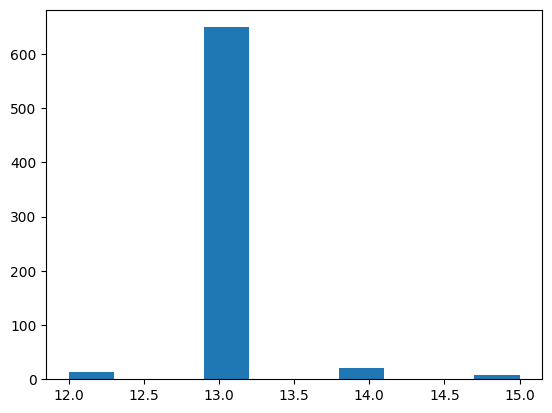

In [131]:
plt.hist(np.sum(LOO_weights > 0, axis = ( 3))[:, 0].flatten())
#plt.scatter(np.sum(LOO_weights > 0, axis = (3))[:, 0].flatten(), 

In [132]:
def AIC_weights(AICs):
    exp_AICs = np.exp(-0.5 * (AICs - np.min(AICs)))
    return exp_AICs / np.sum(exp_AICs)

In [133]:

#LOO_predictions = np.load('weights/LOO_feature_selection_predictions_WLS.npy')
#LOO_weights = np.load('weights/LOO_feature_selection_weights_WLS.npy')
#LOO_predictions.shape

In [134]:
#plt.hist(aic_weights[:5].flatten())

In [135]:
aic_weights = np.zeros((n_fits, 1, data.shape[0]))
for i in range(data.shape[0]):
    aic_weights[:, :, i] = AIC_weights(good_fit_AICs[:, i]).reshape(-1, 1)
LOO_feature_means = np.sum(aic_weights.reshape(n_fits, 1, -1) * LOO_predictions, axis=0)

#LOO_feature_means = np.mean(LOO_predictions, axis=0)

#LOO_feature_means = LOO_predictions.reshape(-1, data.shape[0])

LOO_predictions_mean = np.mean(LOO_feature_means, axis=0)
LOO_predictions_std = np.std(LOO_feature_means, axis=0)
#LOO_predictions.shape

#LOO_predictions_mean = np.mean(LOO_predictions, axis = (0, 1))
#LOO_predictions_std = np.std(LOO_predictions, axis = (0, 1))

In [136]:
LOO_feature_means.shape

(10, 69)

C:\Users\olivi\AppData\Local\Temp\ipykernel_31328\190634855.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sundstrom_data = codes_and_CIs[:25][codes_and_CIs['Source'] == 'Sundstrom et al. 2025']


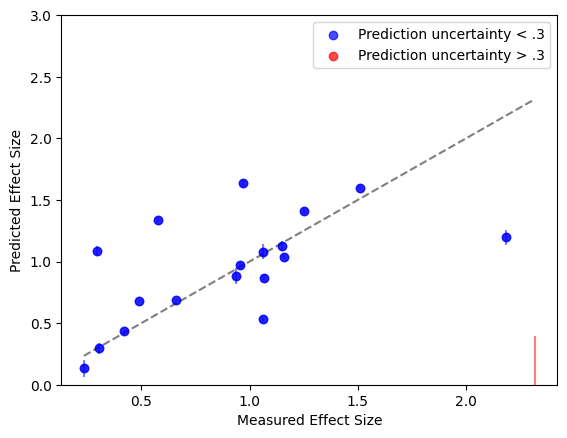

R^2: 0.025
Mean absolute error: 0.5319
-----
R^2 removing high uncertainty: 0.343
MAE removing high uncertainty: 0.2643


In [137]:
#The sundstrom dataset has no repeating instructors or institutions except the following
repeat_institutions = ['ISLE_Course3', 'ISLE_Course4', 'ISLE_Course1', 'PeerInstruction_Course3', 'PeerInstruction_Course4',]

#to make sure there is no overfitting due to instructor or institution
#We remove the repeat institutions from the dataset and re-run LOO on the remaining Sundstrom data
sundstrom_data = codes_and_CIs[:25][codes_and_CIs['Source'] == 'Sundstrom et al. 2025']
sundstrom_classes_no_repeat = sundstrom_data[~sundstrom_data['Course'].isin(repeat_institutions)]

#find the index of those classes in the original data
no_repeat_index = np.where(codes_and_CIs['Course'].isin(sundstrom_classes_no_repeat['Course']))[0]

##plotting LOO predictions with error bars representing uncertainty across different fits
x, y = target[no_repeat_index], LOO_predictions_mean[no_repeat_index]

no_repeat_stds = LOO_predictions_std[no_repeat_index]
plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

where_low_error = np.where(no_repeat_stds < .3)
where_high_error = np.where(no_repeat_stds >= .3)
low_x, low_y = x[where_low_error], y[where_low_error]
high_x, high_y = x[where_high_error], y[where_high_error]

m, b = np.polyfit(x, y, 1)
xi = np.linspace(np.min(x), np.max(x), 100)


plt.scatter(low_x, low_y, label='Prediction uncertainty < .3', color='blue', alpha=0.7)
plt.errorbar(low_x, low_y, yerr=no_repeat_stds[where_low_error], fmt='o', color='blue', alpha=0.5)

plt.scatter(high_x, high_y, label='Prediction uncertainty > .3', color='red', alpha=0.7)
plt.errorbar(high_x, high_y, yerr=no_repeat_stds[where_high_error], fmt='o', color='red', alpha=0.5)

plt.xlabel(f'Measured Effect Size')
plt.ylabel(f'Predicted Effect Size')
plt.ylim(0, 3)
#plt.title(f'Leave-One-Out Predictions vs Target')
plt.legend()
plt.savefig('Figs/LOO.png', dpi=300)
plt.show()

print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')
print('-----')
print(f'R^2 removing high uncertainty: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
print(f'MAE removing high uncertainty: {np.mean(np.abs(low_y-low_x)):.4f}')



In [138]:
# what doesn't do anything
#taking out fourth order terms breaks everything
# doing the dropout method just makes everything slightly worse
# lowering the threshold to keep vars does help, but only down to like 3
#

(69,)


(-1.0, 4.0)

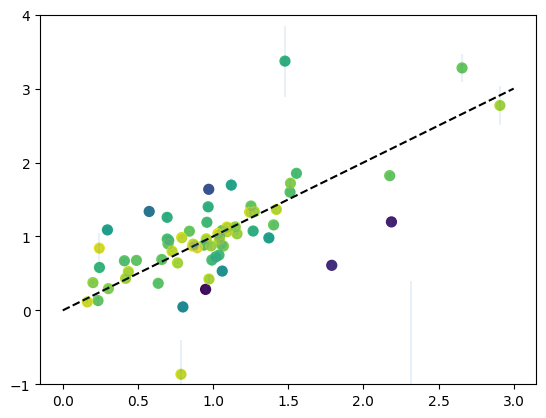

In [139]:
#all_preds = LOO_weights @ data.T
#get only diagonal in axis 2 and 3
#LOO_preds = np.diagonal(all_preds, offset=0, axis1=2, axis2=3)
#LOO_pred_features = np.squeeze(LOO_preds.reshape(-1, 1))
#LOO_pred_features.shape

#LOO_predictions_means = np.mean(LOO_pred_features, axis=0)
#LOO_predictions_stds = np.std(LOO_pred_features, axis=0)
print(LOO_predictions_mean.shape)
mins = np.mean(good_fit_AICs, axis=0)
plt.errorbar(target, LOO_predictions_mean, yerr=LOO_predictions_std, fmt='o',alpha = .1)
plt.scatter(target, LOO_predictions_mean, c=mins, cmap='viridis', s=50)
plt.plot([0, 3], [0, 3], 'k--')
plt.ylim(-1, 4)

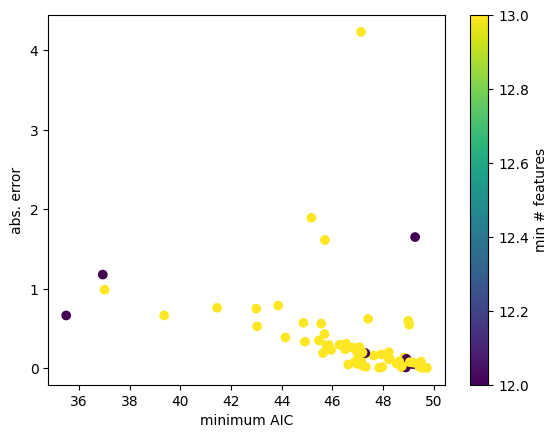

In [140]:
min_AICs = np.min(good_fit_AICs, axis=0)
min_features = np.min(np.sum(LOO_weights > 0, axis = ( 3))[:, 0], axis = 0)
plt.scatter(min_AICs, np.abs(LOO_predictions_mean - target), c= min_features, )
plt.xlabel('minimum AIC')
plt.ylabel('abs. error')
plt.colorbar(label='min # features')

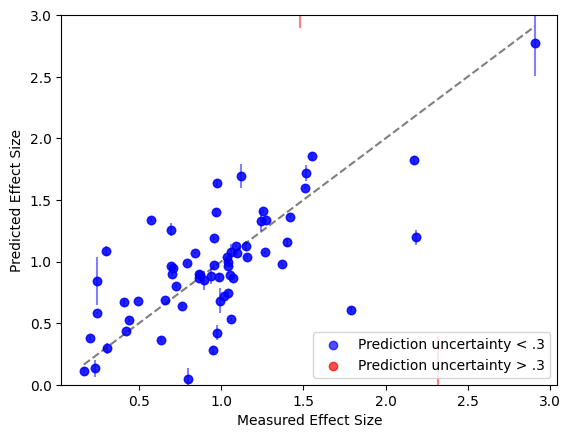

R^2: 0.284
Mean absolute error: 0.3816
-----
R^2 removing high uncertainty: 0.626
MAE removing high uncertainty: 0.2812


In [141]:


##plotting LOO predictions with error bars representing uncertainty across different fits
x, y = target, LOO_predictions_mean
plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

where_low_error = np.where(LOO_predictions_std < .3)
where_high_error = np.where(LOO_predictions_std >= .3)
low_x, low_y = x[where_low_error], y[where_low_error]
high_x, high_y = x[where_high_error], y[where_high_error]

m, b = np.polyfit(x, y, 1)
xi = np.linspace(np.min(x), np.max(x), 100)


plt.scatter(low_x, low_y, label='Prediction uncertainty < .3', color='blue', alpha=0.7)
plt.errorbar(low_x, low_y, yerr=LOO_predictions_std[where_low_error], fmt='o', color='blue', alpha=0.5)

plt.scatter(high_x, high_y, label='Prediction uncertainty > .3', color='red', alpha=0.7)
plt.errorbar(high_x, high_y, yerr=LOO_predictions_std[where_high_error], fmt='o', color='red', alpha=0.5)

plt.xlabel(f'Measured Effect Size')
plt.ylabel(f'Predicted Effect Size')
plt.ylim(0, 3)
#plt.title(f'Leave-One-Out Predictions vs Target')
plt.legend()
plt.savefig('Figs/LOO.png', dpi=300)
plt.show()

print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')
print('-----')
print(f'R^2 removing high uncertainty: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
print(f'MAE removing high uncertainty: {np.mean(np.abs(low_y-low_x)):.4f}')

MAE by field:
Physics MAE: 0.4947
Biology MAE: 0.6697
Astronomy MAE: 0.3611

MAE by class size (N):
N < 50 MAE: 0.5073
50 < N < 150 MAE: 0.4646
N > 150 MAE: 1.0400


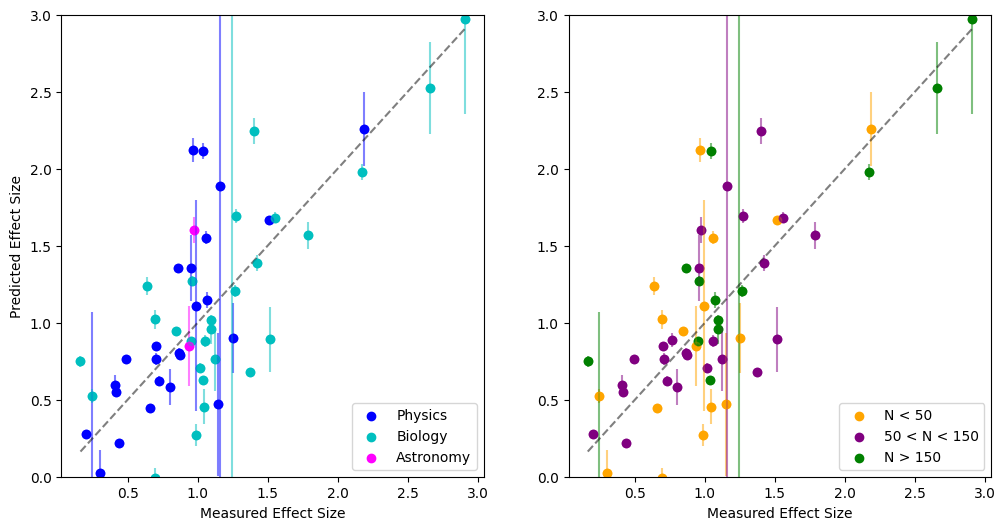

In [114]:
x, y = target, LOO_predictions_mean
fields = codes_and_CIs['Field'].values
Ns = codes_and_CIs['N'].values


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
print('MAE by field:')
#show points colored by field
for field, color in zip(np.unique(fields)[::-1], ['b', 'c','magenta', ]):
    field_x = x[fields == field]
    field_y = y[fields == field]
    field_err = LOO_predictions_std[fields == field]
    ax[0].scatter(field_x, field_y,  c = color, label=field, )
    ax[0].errorbar(field_x, field_y, yerr=field_err, fmt='o',  color=color, alpha = .5)
    field_reliable = np.where(field_err < .3)
    print(f'{field} MAE: {np.mean(np.abs(field_y[field_reliable]-field_x[field_reliable])):.4f}')
print('')

ax[0].plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)
ax[0].set_xlabel(f'Measured Effect Size')
ax[0].set_ylabel(f'Predicted Effect Size')
ax[0].legend()
#ax[0].set_title(f'LOO Predictions vs Target by Field')
ax[0].set_ylim(0, 3)

#separately plot N < 50  50 < N < 100, and N > 100
N_labels = ['N < 50', '50 < N < 150', 'N > 150']
print('MAE by class size (N):')
for N_range, color, label, i in zip([[0, 50], [50, 150],  [150, np.inf]], ['orange', 'purple', 'g'], N_labels, range(3)):
    where = (Ns > N_range[0]) & (Ns <= N_range[1])
    range_x = x[where]
    range_y = y[where]
    range_err = LOO_predictions_std[where]
    ax[1].scatter(range_x, range_y,  color=color,label = label,)
    ax[1].errorbar(range_x, range_y, yerr=range_err, fmt='o', color=color,  alpha = .5)
    print(f'{label} MAE: {np.mean(np.abs(range_y[range_err < .3]-range_x[range_err < .3])):.4f}')
ax[1].legend()
#ax[1].set_title(f'LOO Predictions vs Target by Class Size (N)')
ax[1].plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)
ax[1].set_xlabel(f'Measured Effect Size')
ax[1].set_ylim(0, 3)
plt.savefig('Figs/LOO_N_Field.png', dpi=300)
plt.show()
